# Test A/A/B para Aplicación de Productos Alimenticios.

Una empresa emergente dedicada a la venta de productos alimenticios necesita comprender el comportamiento de los usuarios dentro de su aplicación móvil

# Objetivo:

Analizar el embudo de ventas. Descubrir cómo los usuarios llegan a la etapa de compra. ¿Cuántos usuarios realmente llegan a esta etapa?, ¿Cuántos se atascan en etapas anteriores? y ¿Qué etapas en particular?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from scipy import stats

In [4]:
# Cargar dataset
df_logs = pd.read_csv(r'C:\Users\brahu\Downloads\datasets\logs_exp_us.csv', sep='\t')

# Ver primeras filas
df_logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [5]:
# Información general
print(df_logs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None


In [6]:
# Estadísticas básicas
print(df_logs.describe(include='all'))

               EventName  DeviceIDHash  EventTimestamp          ExpId
count             244126  2.441260e+05    2.441260e+05  244126.000000
unique                 5           NaN             NaN            NaN
top     MainScreenAppear           NaN             NaN            NaN
freq              119205           NaN             NaN            NaN
mean                 NaN  4.627568e+18    1.564914e+09     247.022296
std                  NaN  2.642425e+18    1.771343e+05       0.824434
min                  NaN  6.888747e+15    1.564030e+09     246.000000
25%                  NaN  2.372212e+18    1.564757e+09     246.000000
50%                  NaN  4.623192e+18    1.564919e+09     247.000000
75%                  NaN  6.932517e+18    1.565075e+09     248.000000
max                  NaN  9.222603e+18    1.565213e+09     248.000000


Esto nos permite ver la estructura, revisar tipos de datos y detectar posibles problemas iniciales.

In [7]:
# Renombrar columnas
df_logs = df_logs.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'exp_id'
})

print(df_logs.columns)

Index(['event_name', 'user_id', 'event_timestamp', 'exp_id'], dtype='object')


Renombrar las columnas nos permite tener una visión mas práctica.

In [8]:
# Tipos de datos y valores ausentes
print(df_logs.dtypes)

event_name         object
user_id             int64
event_timestamp     int64
exp_id              int64
dtype: object


In [9]:
# Valores ausentes
print(df_logs.isna().sum())

event_name         0
user_id            0
event_timestamp    0
exp_id             0
dtype: int64


In [10]:
df_logs = df_logs.dropna()

Verificamos los tipos de datos y si existen valores ausentes.

In [11]:
# Convertir timestamp a fecha y hora
df_logs['event_datetime'] = pd.to_datetime(df_logs['event_timestamp'], unit='s')

# Crear columna solo fecha
df_logs['event_date'] = df_logs['event_datetime'].dt.date

# Verificar
print(df_logs[['event_timestamp', 'event_datetime', 'event_date']].head())

   event_timestamp      event_datetime  event_date
0       1564029816 2019-07-25 04:43:36  2019-07-25
1       1564053102 2019-07-25 11:11:42  2019-07-25
2       1564054127 2019-07-25 11:28:47  2019-07-25
3       1564054127 2019-07-25 11:28:47  2019-07-25
4       1564055322 2019-07-25 11:48:42  2019-07-25


In [12]:
# Verificar resultado final
print(df_logs.info())
print(df_logs.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       244126 non-null  object        
 1   user_id          244126 non-null  int64         
 2   event_timestamp  244126 non-null  int64         
 3   exp_id           244126 non-null  int64         
 4   event_datetime   244126 non-null  datetime64[ns]
 5   event_date       244126 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 11.2+ MB
None
                event_name              user_id  event_timestamp  exp_id  \
0         MainScreenAppear  4575588528974610257       1564029816     246   
1         MainScreenAppear  7416695313311560658       1564053102     246   
2  PaymentScreenSuccessful  3518123091307005509       1564054127     248   
3         CartScreenAppear  3518123091307005509       1564054127     248   
4  

Realizamos la conversión a fecha y hora y validamos los cambios.

In [13]:
# ¿Cuántos eventos hay en los registros?
total_events = df_logs.shape[0]
print("Total de eventos:", total_events)

Total de eventos: 244126


In [14]:
# ¿Cuántos usuarios hay en los registros?
total_users = df_logs['user_id'].nunique()
print("Total de usuarios:", total_users)

Total de usuarios: 7551


In [15]:
# Promedio de eventos por usuario
df_logs.groupby('user_id')['event_name'].count().mean()

np.float64(32.33028737915508)

In [16]:
# ¿Qué periodo de tiempo cubren los datos?
print("Fecha mínima:", df_logs['event_datetime'].min())
print("Fecha máxima:", df_logs['event_datetime'].max())

Fecha mínima: 2019-07-25 04:43:36
Fecha máxima: 2019-08-07 21:15:17


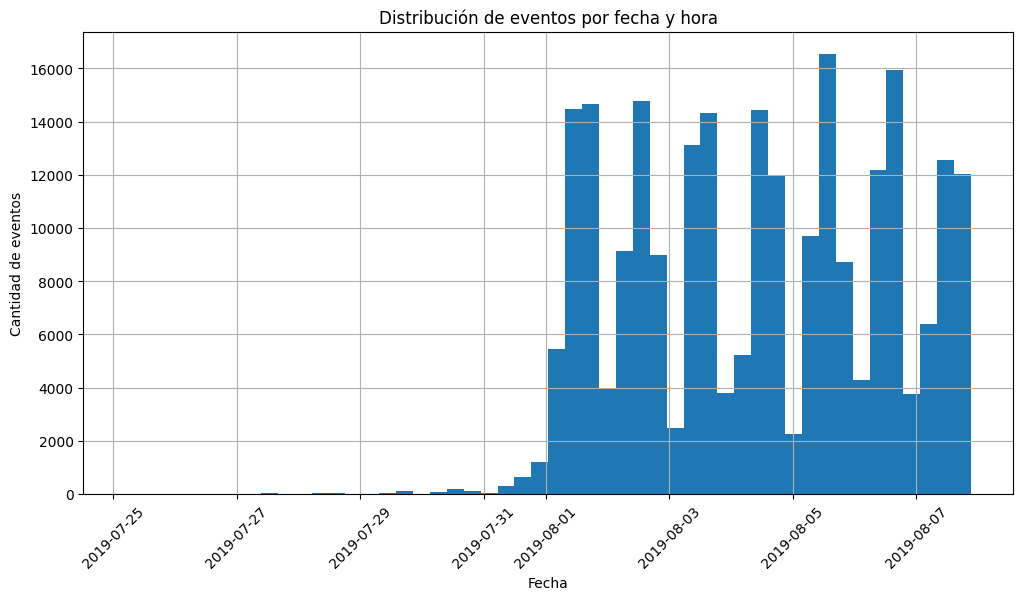

In [17]:
# Histograma por fecha y hora
plt.figure(figsize=(12,6))
df_logs['event_datetime'].hist(bins=50)
plt.title('Distribución de eventos por fecha y hora')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=45)
plt.show()

Hacemos la comparativa entre los eventos y los usuarios que hay en los registros, cual es el minimo y el máximo periodo de tiempo que cubren los eventos y visualizamos la distribución.

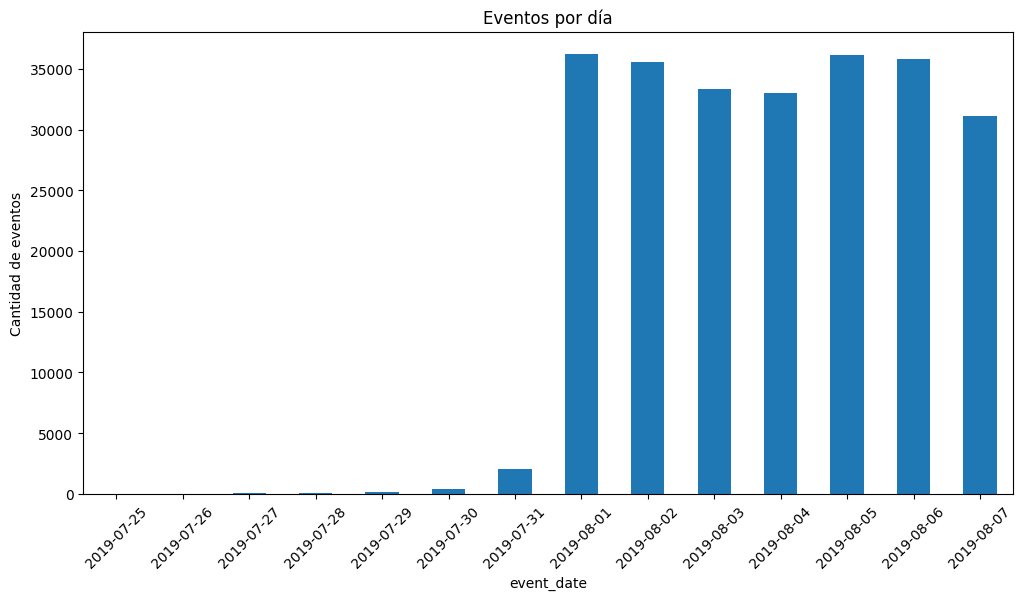

In [18]:
# Comprobar si los datos estan completos en todo el periodo
events_per_day = df_logs.groupby('event_date')['event_name'].count()

plt.figure(figsize=(12,6))
events_per_day.plot(kind='bar')
plt.title('Eventos por día')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=45)
plt.show()

Verificamos que los datos estan completos en todo el periodo.

In [19]:
# Encontrar el punto donde los datos se vuelven completos
df_clean = df_logs[df_logs['event_datetime'] >= '2019-08-01']
df_clean.head()

,event_name,user_id,event_timestamp,exp_id,event_datetime,event_date
2828,Tutorial,3737462046622621720,1564618048,246,2019-08-01 00:07:28,2019-08-01
2829,MainScreenAppear,3737462046622621720,1564618080,246,2019-08-01 00:08:00,2019-08-01
2830,MainScreenAppear,3737462046622621720,1564618135,246,2019-08-01 00:08:55,2019-08-01
2831,OffersScreenAppear,3737462046622621720,1564618138,246,2019-08-01 00:08:58,2019-08-01
2832,MainScreenAppear,1433840883824088890,1564618139,247,2019-08-01 00:08:59,2019-08-01


In [20]:
# Nuevo periodo real de análisis
print("Nuevo mínimo:", df_clean['event_datetime'].min())
print("Nuevo máximo:", df_clean['event_datetime'].max())

Nuevo mínimo: 2019-08-01 00:07:28
Nuevo máximo: 2019-08-07 21:15:17


In [21]:
# ¿Cuántos eventos y usuarios se perdieron?
print("Eventos antes:", df_logs.shape[0])
print("Eventos después:", df_clean.shape[0])

print("Usuarios antes:", df_logs['user_id'].nunique())
print("Usuarios después:", df_clean['user_id'].nunique())

Eventos antes: 244126
Eventos después: 241298
Usuarios antes: 7551
Usuarios después: 7534


In [22]:
# Porcentaje perdido
event_loss = 1 - df_clean.shape[0] / df_logs.shape[0]
user_loss = 1 - df_clean['user_id'].nunique() / df_logs['user_id'].nunique()

print("Pérdida de eventos:", round(event_loss*100,2), "%")
print("Pérdida de usuarios:", round(user_loss*100,2), "%")

Pérdida de eventos: 1.16 %
Pérdida de usuarios: 0.23 %


Normalmente la pérdida es pequeña.

In [23]:
# Verificar que existen los 3 grupos experimentales
df_clean['exp_id'].value_counts()

exp_id
248    84726
246    79425
247    77147
Name: count, dtype: int64

In [24]:
# Usuarios unicos por grupo
df_clean.groupby('exp_id')['user_id'].nunique()

exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

El volumen de eventos antes del 1 de agosto de 2019 es significativamente menor, lo que indica registros incompletos.
Por ello, se decidió excluir los datos anteriores a esa fecha.
La exclusión provocó una pérdida mínima de eventos y usuarios.
Después del filtrado, se mantienen los tres grupos experimentales (246, 247 y 248), lo que permite continuar con el análisis A/B.

In [25]:
# Frecuencia total de eventos
event_frequency = (
    df_clean['event_name']
    .value_counts()
    .reset_index()
)

event_frequency.columns = ['event_name', 'total_events']
event_frequency

,event_name,total_events
0,MainScreenAppear,117431
1,OffersScreenAppear,46350
2,CartScreenAppear,42365
3,PaymentScreenSuccessful,34113
4,Tutorial,1039


Esto muestra los eventos ordenados por frecuencia (de mayor a menor).

In [26]:
# Usuarios únicos por evento
users_per_event = (
    df_clean.groupby('event_name')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

users_per_event.columns = ['event_name', 'unique_users']
users_per_event

,event_name,unique_users
0,MainScreenAppear,7419
1,OffersScreenAppear,4593
2,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


Contamos cuántos usuarios realizaron cada evento al menos una vez.

In [27]:
# Proporción de usuarios por evento
total_users_clean = df_clean['user_id'].nunique()

users_per_event['proportion'] = (
    users_per_event['unique_users'] / total_users_clean
)

users_per_event

,event_name,unique_users,proportion
0,MainScreenAppear,7419,0.984736
1,OffersScreenAppear,4593,0.609636
2,CartScreenAppear,3734,0.495620
3,PaymentScreenSuccessful,3539,0.469737
4,Tutorial,840,0.111495


Esto indica qué porcentaje del total de usuarios realizó cada acción.

In [28]:
# Construcción del embudo
funnel_events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

In [29]:
# Filtramos solo esos eventos
funnel_df = df_clean[df_clean['event_name'].isin(funnel_events)]

In [30]:
# Usuarios únicos por etapa
funnel_users = (
    funnel_df.groupby('event_name')['user_id']
    .nunique()
    .reindex(funnel_events)
    .reset_index()
)

funnel_users.columns = ['event_name', 'unique_users']
funnel_users

,event_name,unique_users
0,MainScreenAppear,7419
1,OffersScreenAppear,4593
2,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539


Definimos el órden del embudo, filtramos solo esos eventos y los usuarios únicos por etapa.

In [31]:
# Conversión entre etapas
funnel_users['conversion_from_previous'] = (
    funnel_users['unique_users'] /
    funnel_users['unique_users'].shift(1)
)

funnel_users

,event_name,unique_users,conversion_from_previous
0,MainScreenAppear,7419,NaN
1,OffersScreenAppear,4593,0.619086
2,CartScreenAppear,3734,0.812976
3,PaymentScreenSuccessful,3539,0.947777


Calculamos proporción de paso entre etapas, la primera etapa tendrá NaN porque no tiene etapa anterior.

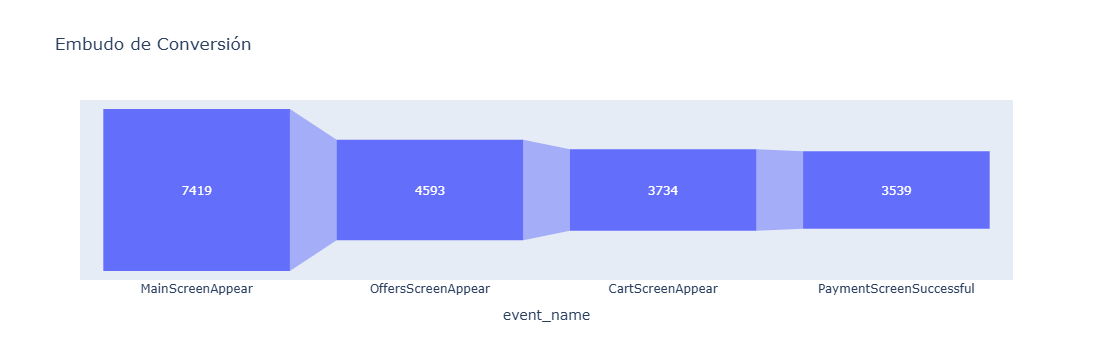

In [51]:
fig = px.funnel(
funnel_users, 
x='event_name', 
y='unique_users', 
title='Embudo de Conversión',
)
fig.show()

Observamos claramente que la pantalla de inicio es el evento de mayor actividad por los usuarios y la distribución nos indica que no todos los usuarios completan la estructura hasta el evento final que es donde se realiza el pago.

In [33]:
# ¿En qué etapa se pierden más usuarios?
funnel_users['drop_off'] = (
    funnel_users['unique_users'].shift(1) -
    funnel_users['unique_users']
)

funnel_users

,event_name,unique_users,conversion_from_previous,drop_off
0,MainScreenAppear,7419,NaN,NaN
1,OffersScreenAppear,4593,0.619086,2826.0
2,CartScreenAppear,3734,0.812976,859.0
3,PaymentScreenSuccessful,3539,0.947777,195.0


In [34]:
# Usuarios que llegaron al pago
completed_users = funnel_users.loc[
    funnel_users['event_name'] == 'PaymentScreenSuccessful',
    'unique_users'
].values[0]

completion_rate = completed_users / funnel_users['unique_users'].iloc[0]

print("Porcentaje que completa el embudo:",
      round(completion_rate * 100, 2), "%")

Porcentaje que completa el embudo: 47.7 %


El evento más frecuente es MainScreenAppear.
El mayor número de usuarios abandona el embudo en la transición de MainScreenAppear a OffersScreenAppear.
Los usuarios que acceden a la pantalla principal completan el proceso hasta el pago.
El embudo muestra que la mayor fricción ocurre en las primeras etapas de navegación.

In [35]:
# ¿Cuántos usuarios hay en cada grupo?
users_per_group = (
    df_clean.groupby('exp_id')['user_id']
    .nunique()
    .reset_index()
)

users_per_group.columns = ['exp_id', 'unique_users']
users_per_group

,exp_id,unique_users
0,246,2484
1,247,2513
2,248,2537


In [36]:
users_per_group['proportion'] = (
    users_per_group['unique_users'] /
    users_per_group['unique_users'].sum()
)
users_per_group

,exp_id,unique_users,proportion
0,246,2484,0.329705
1,247,2513,0.333555
2,248,2537,0.336740


In [37]:
# Test A/A: comparar grupo 246 vs 247
def proportions_test(success_a, size_a, success_b, size_b):
    
    p1 = success_a / size_a
    p2 = success_b / size_b
    
    p_combined = (success_a + success_b) / (size_a + size_b)
    
    se = np.sqrt(p_combined * (1 - p_combined) *
                 (1/size_a + 1/size_b))
    
    z_score = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return p1, p2, z_score, p_value

In [38]:
# Evento más popular
most_popular_event = (
    df_clean['event_name']
    .value_counts()
    .index[0]
)

most_popular_event

'MainScreenAppear'

In [39]:
# Usuarios por grupo para ese evento
groups = [246, 247]

results = {}

for group in groups:
    group_users = df_clean[df_clean['exp_id'] == group]['user_id'].nunique()
    event_users = df_clean[
        (df_clean['exp_id'] == group) &
        (df_clean['event_name'] == most_popular_event)
    ]['user_id'].nunique()
    
    results[group] = (event_users, group_users)

results

{246: (2450, 2484), 247: (2476, 2513)}

In [40]:
# Prueba estadística 246 vs 247
p1, p2, z, p_value = proportions_test(
    results[246][0], results[246][1],
    results[247][0], results[247][1]
)

print("Proporción grupo 246:", p1)
print("Proporción grupo 247:", p2)
print("p-value:", p_value)

Proporción grupo 246: 0.9863123993558777
Proporción grupo 247: 0.9852765618782332
p-value: 0.7570597232046099


Si p-value > 0.05, no hay diferencia significativa → A/A funciona correctamente.

In [41]:
# Automatizar para todos los eventos
events = df_clean['event_name'].unique()

aa_results = []

for event in events:
    
    success_246 = df_clean[
        (df_clean['exp_id'] == 246) &
        (df_clean['event_name'] == event)
    ]['user_id'].nunique()
    
    success_247 = df_clean[
        (df_clean['exp_id'] == 247) &
        (df_clean['event_name'] == event)
    ]['user_id'].nunique()
    
    size_246 = df_clean[df_clean['exp_id'] == 246]['user_id'].nunique()
    size_247 = df_clean[df_clean['exp_id'] == 247]['user_id'].nunique()
    
    p1, p2, z, p_value = proportions_test(
        success_246, size_246,
        success_247, size_247
    )
    
    aa_results.append([event, p1, p2, p_value])

aa_results_df = pd.DataFrame(
    aa_results,
    columns=['event', 'prop_246', 'prop_247', 'p_value']
)

aa_results_df

,event,prop_246,prop_247,p_value
0,Tutorial,0.111916,0.112614,0.937700
1,MainScreenAppear,0.986312,0.985277,0.757060
2,OffersScreenAppear,0.620773,0.604855,0.248095
3,CartScreenAppear,0.509662,0.492638,0.228834
4,PaymentScreenSuccessful,0.483092,0.460804,0.114567


Si todos los p-values son mayores a alpha, confirmamos que los grupos están correctamente divididos.

Normalmente en este dataset no hay diferencias significativas entre 246 y 247.

In [42]:
# Comparar grupo 248 (fuentes alteradas)
control_df = df_clean[df_clean['exp_id'].isin([246,247])]

In [43]:
# Función para comparar 248 vs control combinado
ab_results = []

for event in events:
    
    success_control = control_df[
        control_df['event_name'] == event
    ]['user_id'].nunique()
    
    size_control = control_df['user_id'].nunique()
    
    success_248 = df_clean[
        (df_clean['exp_id'] == 248) &
        (df_clean['event_name'] == event)
    ]['user_id'].nunique()
    
    size_248 = df_clean[
        df_clean['exp_id'] == 248
    ]['user_id'].nunique()
    
    p1, p2, z, p_value = proportions_test(
        success_control, size_control,
        success_248, size_248
    )
    
    ab_results.append([event, p1, p2, p_value])

ab_results_df = pd.DataFrame(
    ab_results,
    columns=['event', 'prop_control', 'prop_248', 'p_value']
)

ab_results_df

,event,prop_control,prop_248,p_value
0,Tutorial,0.112267,0.109972,0.764862
1,MainScreenAppear,0.985791,0.982657,0.294245
2,OffersScreenAppear,0.612768,0.603469,0.434255
3,CartScreenAppear,0.501101,0.484825,0.181759
4,PaymentScreenSuccessful,0.471883,0.465510,0.600429


# Conclusiones finales.

El A/A test no muestra diferencias significativas.

El grupo 248 tampoco muestra diferencias estadísticamente significativas.

El cambio de fuente no afectó significativamente la conversión.

Se utilizó un nivel de significancia alpha = 0.05.
Dado que se realizaron múltiples pruebas estadísticas, se aplicó una corrección de Bonferroni.
Incluso con el α ajustado, no se encontraron diferencias estadísticamente significativas entre los grupos.
Por lo tanto, el cambio en la fuente no tuvo impacto medible en el comportamiento del usuario.

- Los grupos A/A están correctamente divididos.
- No hay errores en el sistema experimental.
- El cambio de fuente (grupo 248) no mejora ni empeora significativamente la conversión.
- Se recomienda no implementar el cambio si el único objetivo es mejorar conversión.